# Обучение моделей оценки стоимости недвижимости

В ноутбуке выполняется:
- загрузка очищенного датасета
- подготовка признаков
- обучение Ridge и CatBoost
- оценка качества по MAE и MAPE
- сохранение предсказаний и важности признаков
- построение графиков ошибок

In [22]:
!git clone https://github.com/moretskayalv/parser_realty_vkr.git
%cd parser_realty_vkr
!ls

Cloning into 'parser_realty_vkr'...
remote: Enumerating objects: 63, done.
remote: Counting objects: 100% (63/63), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 63 (delta 23), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (63/63), 1.35 MiB | 11.78 MiB/s, done.
Resolving deltas: 100% (23/23), done.
/content/parser_realty_vkr/parser_realty_vkr
Clean_dataset_and_plots.ipynb  data_raw.csv  parser_realty_2.py
clean_dataset.py	       eda_plots.py  plots
data_clean.csv		       links.txt     result.csv


In [23]:
!pip install catboost -q

In [24]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display, Image

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error
from sklearn.linear_model import Ridge

from catboost import CatBoostRegressor


REPO_DIR = Path("/content/parser_realty_vkr")
INPUT_FILE = REPO_DIR / "data_clean.csv"

MODEL_PLOTS_DIR = REPO_DIR / "plots_model"
PRED_FILE = REPO_DIR / "predictions.csv"
IMPORTANCE_FILE = REPO_DIR / "feature_importance.csv"

os.makedirs(MODEL_PLOTS_DIR, exist_ok=True)

print("INPUT_FILE exists:", INPUT_FILE.exists())
print("INPUT_FILE:", INPUT_FILE)

INPUT_FILE exists: True
INPUT_FILE: /content/parser_realty_vkr/data_clean.csv


In [25]:
df = pd.read_csv(INPUT_FILE)

print("Размер датасета:", df.shape)
display(df.head())

Размер датасета: (2521, 16)


,source_group,price,area_total,kitchen_area,price_per_m2,rooms,floor,floors_total,address,metro,metro_walk_min,walls,walls_clean,link,address_raw,metro_raw
0,4k,39990000,114.0,15.0,350789.473684,4.0,10.0,19.0,NaN,NaN,32.0,Монолитный железобетонный каркас,монолит,https://msk.etagi.com/realty/12205369/,Посмотреть 5 фото,Немчиновка
1,4k,32000000,97.4,10.8,328542.094456,4.0,NaN,NaN,"ул. Высоковольтный проезд, 1, Москва",Верхние Лихоборы,21.0,NaN,NaN,https://msk.etagi.com/realty/12219043/,"4к, 97.4м², 10 этаж, ул. Высоковольтный проезд...",На карте Верхние Лихоборы Бибирево
2,4k,20500000,75.7,15.0,270805.812417,4.0,1.0,12.0,"ул. Перерва, 10, Москва",NaN,NaN,Панельные,панель,https://msk.etagi.com/realty/12219804/,"4к, 75.7м², 1/12 этаж, ул. Перерва, 10, Москва...",NaN
3,4k,114000000,125.9,15.0,905480.540111,4.0,25.0,32.0,"ул. Летниковская, 11к1, Москва",Павелецкая,12.0,Монолитные,монолит,https://msk.etagi.com/realty/12227773/,"4к, 125.9м², 25/32 этаж, ул. Летниковская, 11к...",На карте Павелецкая
4,4k,30000000,100.0,13.5,300000.000000,4.0,2.0,14.0,"ул. Лермонтовский проспект, 6, Москва",Косино,3.0,Панельные,панель,https://msk.etagi.com/realty/12233361/,"4к, 100м², 2/14 этаж, ул. Лермонтовский проспе...",На карте Косино


In [26]:
# =========================
# Подготовка данных для модели
# =========================

features = [
    "area_total",
    "rooms",
    "floor",
    "floors_total",
    "kitchen_area",
    "metro_walk_min",
    "walls_clean",
]

target = "price"

df_model = df[features + [target]].copy()

# =========================
# 1. Числовые преобразования
# =========================

num_cols = [
    "area_total",
    "rooms",
    "floor",
    "floors_total",
    "kitchen_area",
    "metro_walk_min",
    "price",
]

for col in num_cols:
    df_model[col] = pd.to_numeric(df_model[col], errors="coerce")

# =========================
# 2. Работа с метро
# =========================

# признак пропуска
df_model["metro_missing"] = df_model["metro_walk_min"].isna().astype(int)

# заполняем медианой
df_model["metro_walk_min"] = df_model["metro_walk_min"].fillna(
    df_model["metro_walk_min"].median()
)

# =========================
# 3. Обработка остальных пропусков
# =========================

# кухня — заполняем медианой
df_model["kitchen_area"] = df_model["kitchen_area"].fillna(
    df_model["kitchen_area"].median()
)

# этажи — можно удалить строки (редко пропущены)
df_model = df_model.dropna(subset=["area_total", "rooms", "floor", "floors_total", "price"])

# =========================
# 4. Удаление inf и NaN
# =========================

df_model = df_model.replace([np.inf, -np.inf], np.nan).dropna()

# =========================
# 5. Фильтрация выбросов (ВАЖНО)
# =========================

df_model = df_model[
    (df_model["price"] >= 2_000_000) &
    (df_model["price"] <= 200_000_000)
]

df_model = df_model[
    (df_model["area_total"] >= 15) &
    (df_model["area_total"] <= 250)
]

df_model = df_model[
    (df_model["kitchen_area"] >= 3) &
    (df_model["kitchen_area"] <= 60)
]

df_model = df_model[
    (df_model["floor"] >= 1) &
    (df_model["floor"] <= 100)
]

df_model = df_model[
    (df_model["floors_total"] >= 1) &
    (df_model["floors_total"] <= 100)
]

df_model = df_model[
    df_model["floor"] <= df_model["floors_total"]
]

df_model = df_model[
    (df_model["metro_walk_min"] >= 1) &
    (df_model["metro_walk_min"] <= 90)
]

# =========================
# 6. Производные признаки (УЛУЧШЕНИЕ)
# =========================

df_model["floor_ratio"] = df_model["floor"] / df_model["floors_total"]

df_model["price_per_m2"] = df_model["price"] / df_model["area_total"]

# =========================
# 7. Итог
# =========================

print("После подготовки:", df_model.shape)
display(df_model.head())

После подготовки: (2375, 11)


,area_total,rooms,floor,floors_total,kitchen_area,metro_walk_min,walls_clean,price,metro_missing,floor_ratio,price_per_m2
0,114.0,4.0,10.0,19.0,15.0,32.0,монолит,39990000,0,0.526316,3.507895e+05
2,75.7,4.0,1.0,12.0,15.0,11.0,панель,20500000,1,0.083333,2.708058e+05
3,125.9,4.0,25.0,32.0,15.0,12.0,монолит,114000000,0,0.781250,9.054805e+05
4,100.0,4.0,2.0,14.0,13.5,3.0,панель,30000000,0,0.142857,3.000000e+05
5,106.2,4.0,2.0,6.0,13.0,8.0,монолит,125000000,0,0.333333,1.177024e+06


In [27]:
df_model = pd.get_dummies(df_model, columns=["walls_clean"], dummy_na=False)

X = df_model.drop(columns=[target])
y = df_model[target]

print("X shape:", X.shape)
print("y shape:", y.shape)

display(X.head())

X shape: (2375, 24)
y shape: (2375,)


,area_total,rooms,floor,floors_total,kitchen_area,metro_walk_min,metro_missing,floor_ratio,price_per_m2,walls_clean_арболитовые,...,walls_clean_железо-бетон,walls_clean_железобетон,walls_clean_камень,walls_clean_кирпич,walls_clean_крупноблочные,walls_clean_монолит,walls_clean_панель,walls_clean_прочее,walls_clean_смешанные,walls_clean_сталинский
0,114.0,4.0,10.0,19.0,15.0,32.0,0,0.526316,3.507895e+05,False,...,False,False,False,False,False,True,False,False,False,False
2,75.7,4.0,1.0,12.0,15.0,11.0,1,0.083333,2.708058e+05,False,...,False,False,False,False,False,False,True,False,False,False
3,125.9,4.0,25.0,32.0,15.0,12.0,0,0.781250,9.054805e+05,False,...,False,False,False,False,False,True,False,False,False,False
4,100.0,4.0,2.0,14.0,13.5,3.0,0,0.142857,3.000000e+05,False,...,False,False,False,False,False,False,True,False,False,False
5,106.2,4.0,2.0,6.0,13.0,8.0,0,0.333333,1.177024e+06,False,...,False,False,False,False,False,True,False,False,False,False


In [28]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Train:", X_train.shape, "Test:", X_test.shape)

Train: (1900, 24) Test: (475, 24)


In [29]:
model_ridge = Ridge(alpha=1.0)
model_ridge.fit(X_train, y_train)

pred_ridge = model_ridge.predict(X_test)

mae_ridge = mean_absolute_error(y_test, pred_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, pred_ridge)

print("Ridge Regression")
print("MAE:", round(mae_ridge, 2))
print("MAPE:", round(mape_ridge * 100, 2), "%")

Ridge Regression
MAE: 2848935.27
MAPE: 16.49 %


In [30]:
model_cb = CatBoostRegressor(
    iterations=700,
    depth=6,
    learning_rate=0.05,
    loss_function="MAE",
    eval_metric="MAE",
    verbose=100,
    random_seed=42
)

model_cb.fit(
    X_train,
    y_train,
    eval_set=(X_test, y_test),
    use_best_model=True
)

pred_cb = model_cb.predict(X_test)

mae_cb = mean_absolute_error(y_test, pred_cb)
mape_cb = mean_absolute_percentage_error(y_test, pred_cb)

print("CatBoost")
print("MAE:", round(mae_cb, 2))
print("MAPE:", round(mape_cb * 100, 2), "%")

0:	learn: 9845113.6920987	test: 8921957.4807293	best: 8921957.4807293 (0)	total: 9.13ms	remaining: 6.38s
100:	learn: 1553354.4521785	test: 1506298.3820907	best: 1506298.3820907 (100)	total: 304ms	remaining: 1.8s
200:	learn: 596587.1618581	test: 823698.3623435	best: 823698.3623435 (200)	total: 488ms	remaining: 1.21s
300:	learn: 438126.6795814	test: 735962.5554461	best: 735962.5554461 (300)	total: 972ms	remaining: 1.29s
400:	learn: 358990.8144971	test: 692833.4693920	best: 692833.4693920 (400)	total: 1.15s	remaining: 858ms
500:	learn: 304154.0533749	test: 677678.6534560	best: 675859.2876301 (497)	total: 1.43s	remaining: 568ms
600:	learn: 270263.8708498	test: 665060.2591804	best: 664806.8094040 (597)	total: 1.91s	remaining: 314ms
699:	learn: 243064.8982468	test: 654070.0331042	best: 654048.3485326 (691)	total: 2.45s	remaining: 0us

bestTest = 654048.3485
bestIteration = 691

Shrink model to first 692 iterations.
CatBoost
MAE: 654048.35
MAPE: 2.14 %


In [31]:
result = X_test.copy()
result["price_real"] = y_test.values
result["price_pred"] = pred_cb
result["delta"] = result["price_pred"] - result["price_real"]
result["abs_error"] = (result["price_real"] - result["price_pred"]).abs()
result["ape"] = result["abs_error"] / result["price_real"] * 100

result.to_csv(PRED_FILE, index=False, encoding="utf-8-sig")
print("Сохранено:", PRED_FILE)

importance = pd.DataFrame({
    "feature": X_train.columns,
    "importance": model_cb.get_feature_importance()
}).sort_values("importance", ascending=False)

importance.to_csv(IMPORTANCE_FILE, index=False, encoding="utf-8-sig")
print("Сохранено:", IMPORTANCE_FILE)

display(result.head())
display(importance.head(15))

Сохранено: /content/parser_realty_vkr/predictions.csv
Сохранено: /content/parser_realty_vkr/feature_importance.csv


,area_total,rooms,floor,floors_total,kitchen_area,metro_walk_min,metro_missing,floor_ratio,price_per_m2,walls_clean_арболитовые,...,walls_clean_монолит,walls_clean_панель,walls_clean_прочее,walls_clean_смешанные,walls_clean_сталинский,price_real,price_pred,delta,abs_error,ape
2169,57.9,2.0,33.0,33.0,21.3,20.0,0,1.000000,373056.994819,False,...,False,True,False,False,False,21600000,2.177723e+07,1.772307e+05,1.772307e+05,0.820512
1906,34.0,1.0,1.0,12.0,9.5,11.0,1,0.083333,352941.176471,False,...,False,False,False,False,False,12000000,1.209490e+07,9.490252e+04,9.490252e+04,0.790854
111,59.2,3.0,6.0,9.0,6.0,6.0,0,0.666667,365709.459459,False,...,False,True,False,False,False,21650000,2.171089e+07,6.088884e+04,6.088884e+04,0.281242
2422,95.9,3.0,18.0,29.0,9.5,2.0,0,0.620690,375391.032325,False,...,True,False,False,False,False,36000000,3.486507e+07,-1.134931e+06,1.134931e+06,3.152585
64,80.5,3.0,21.0,27.0,26.0,5.0,0,0.777778,681987.577640,False,...,True,False,False,False,False,54900000,5.502262e+07,1.226223e+05,1.226223e+05,0.223356


,feature,importance
0,area_total,47.972435
8,price_per_m2,43.069851
1,rooms,2.706225
4,kitchen_area,2.676069
3,floors_total,0.911575
7,floor_ratio,0.822030
6,metro_missing,0.607667
2,floor,0.582087
5,metro_walk_min,0.328160
19,walls_clean_монолит,0.144089


In [32]:
def save_and_show(fig, filename):
    path = MODEL_PLOTS_DIR / filename
    fig.savefig(path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=str(path)))

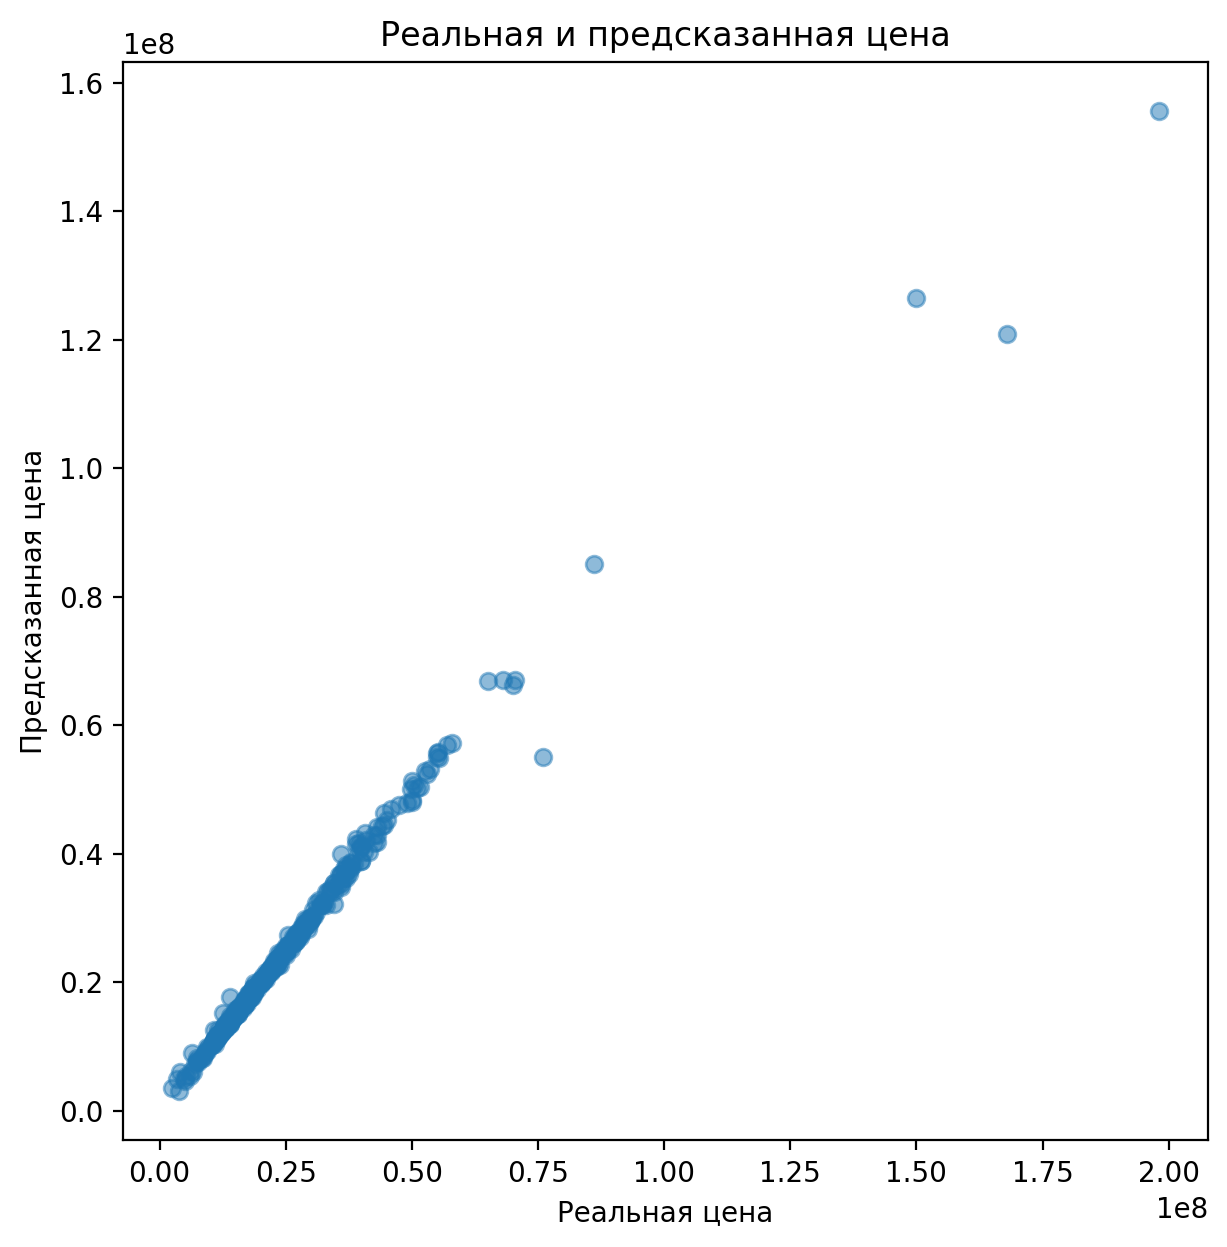

In [33]:
# 1. Реальная цена vs предсказанная
sample = result[["price_real", "price_pred"]].dropna().sample(
    min(500, len(result)),
    random_state=42
)

fig = plt.figure(figsize=(7, 7))
plt.scatter(sample["price_real"], sample["price_pred"], alpha=0.5)
plt.xlabel("Реальная цена")
plt.ylabel("Предсказанная цена")
plt.title("Реальная и предсказанная цена")
save_and_show(fig, "real_vs_pred.png")

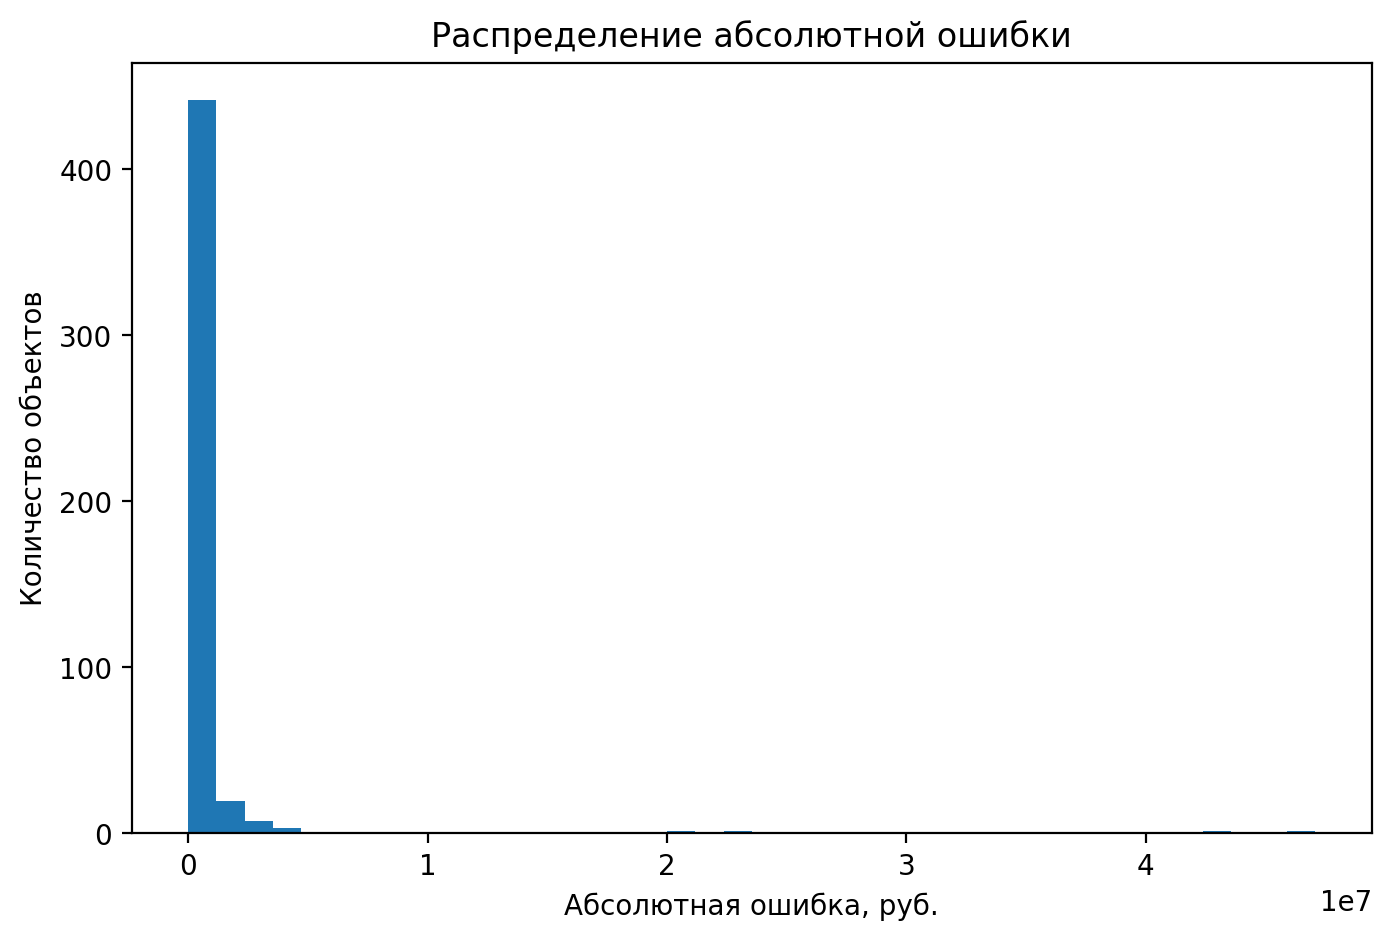

In [34]:
# 2. Распределение абсолютной ошибки
fig = plt.figure(figsize=(8, 5))
plt.hist(result["abs_error"].dropna(), bins=40)
plt.xlabel("Абсолютная ошибка, руб.")
plt.ylabel("Количество объектов")
plt.title("Распределение абсолютной ошибки")
save_and_show(fig, "abs_error_distribution.png")

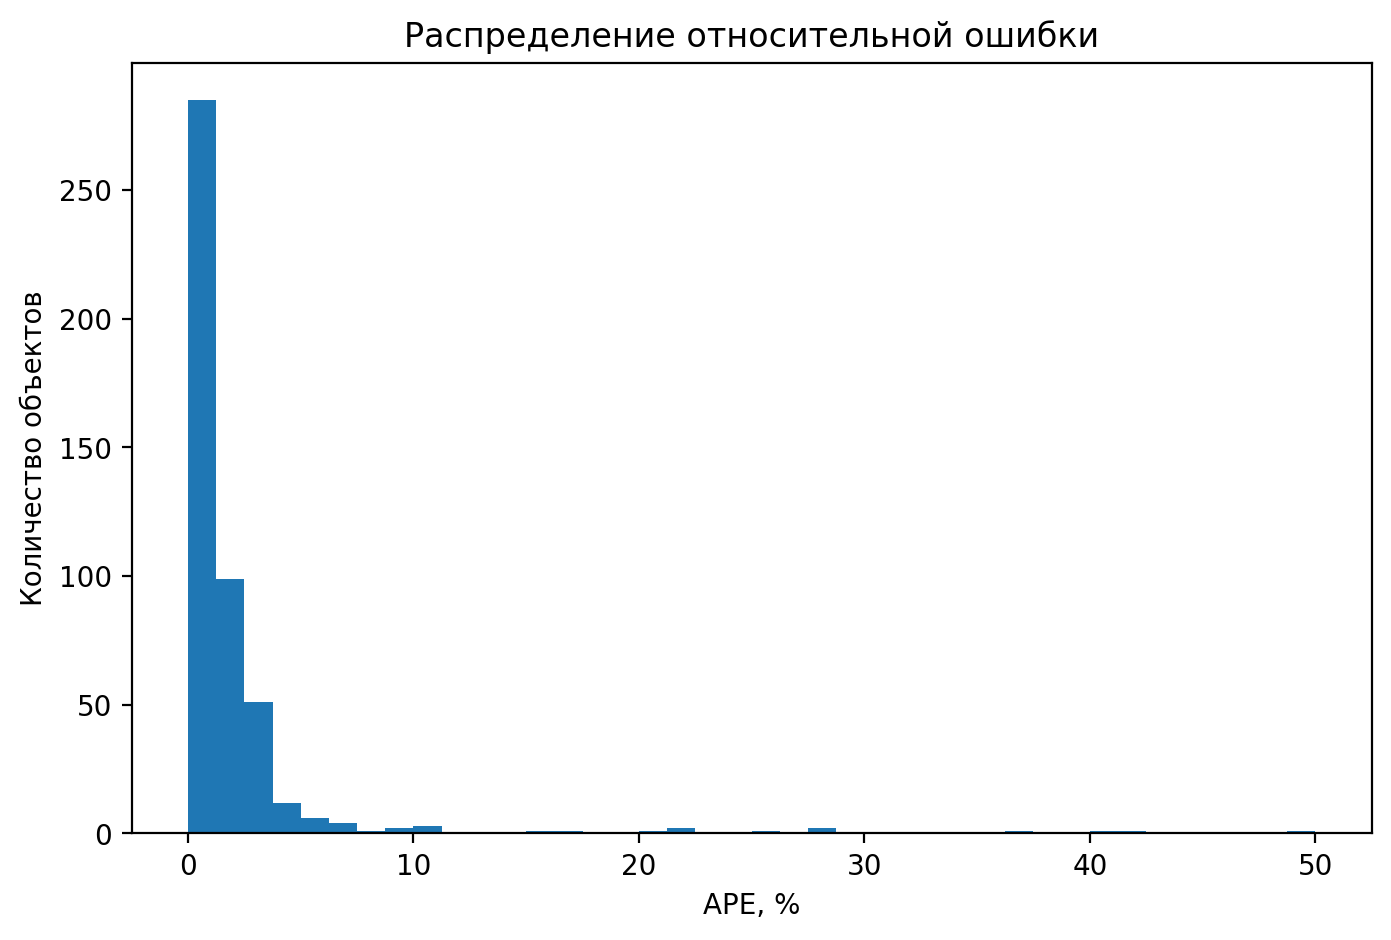

In [35]:
# 3. Распределение APE
fig = plt.figure(figsize=(8, 5))
plt.hist(result["ape"].dropna(), bins=40)
plt.xlabel("APE, %")
plt.ylabel("Количество объектов")
plt.title("Распределение относительной ошибки")
save_and_show(fig, "ape_distribution.png")

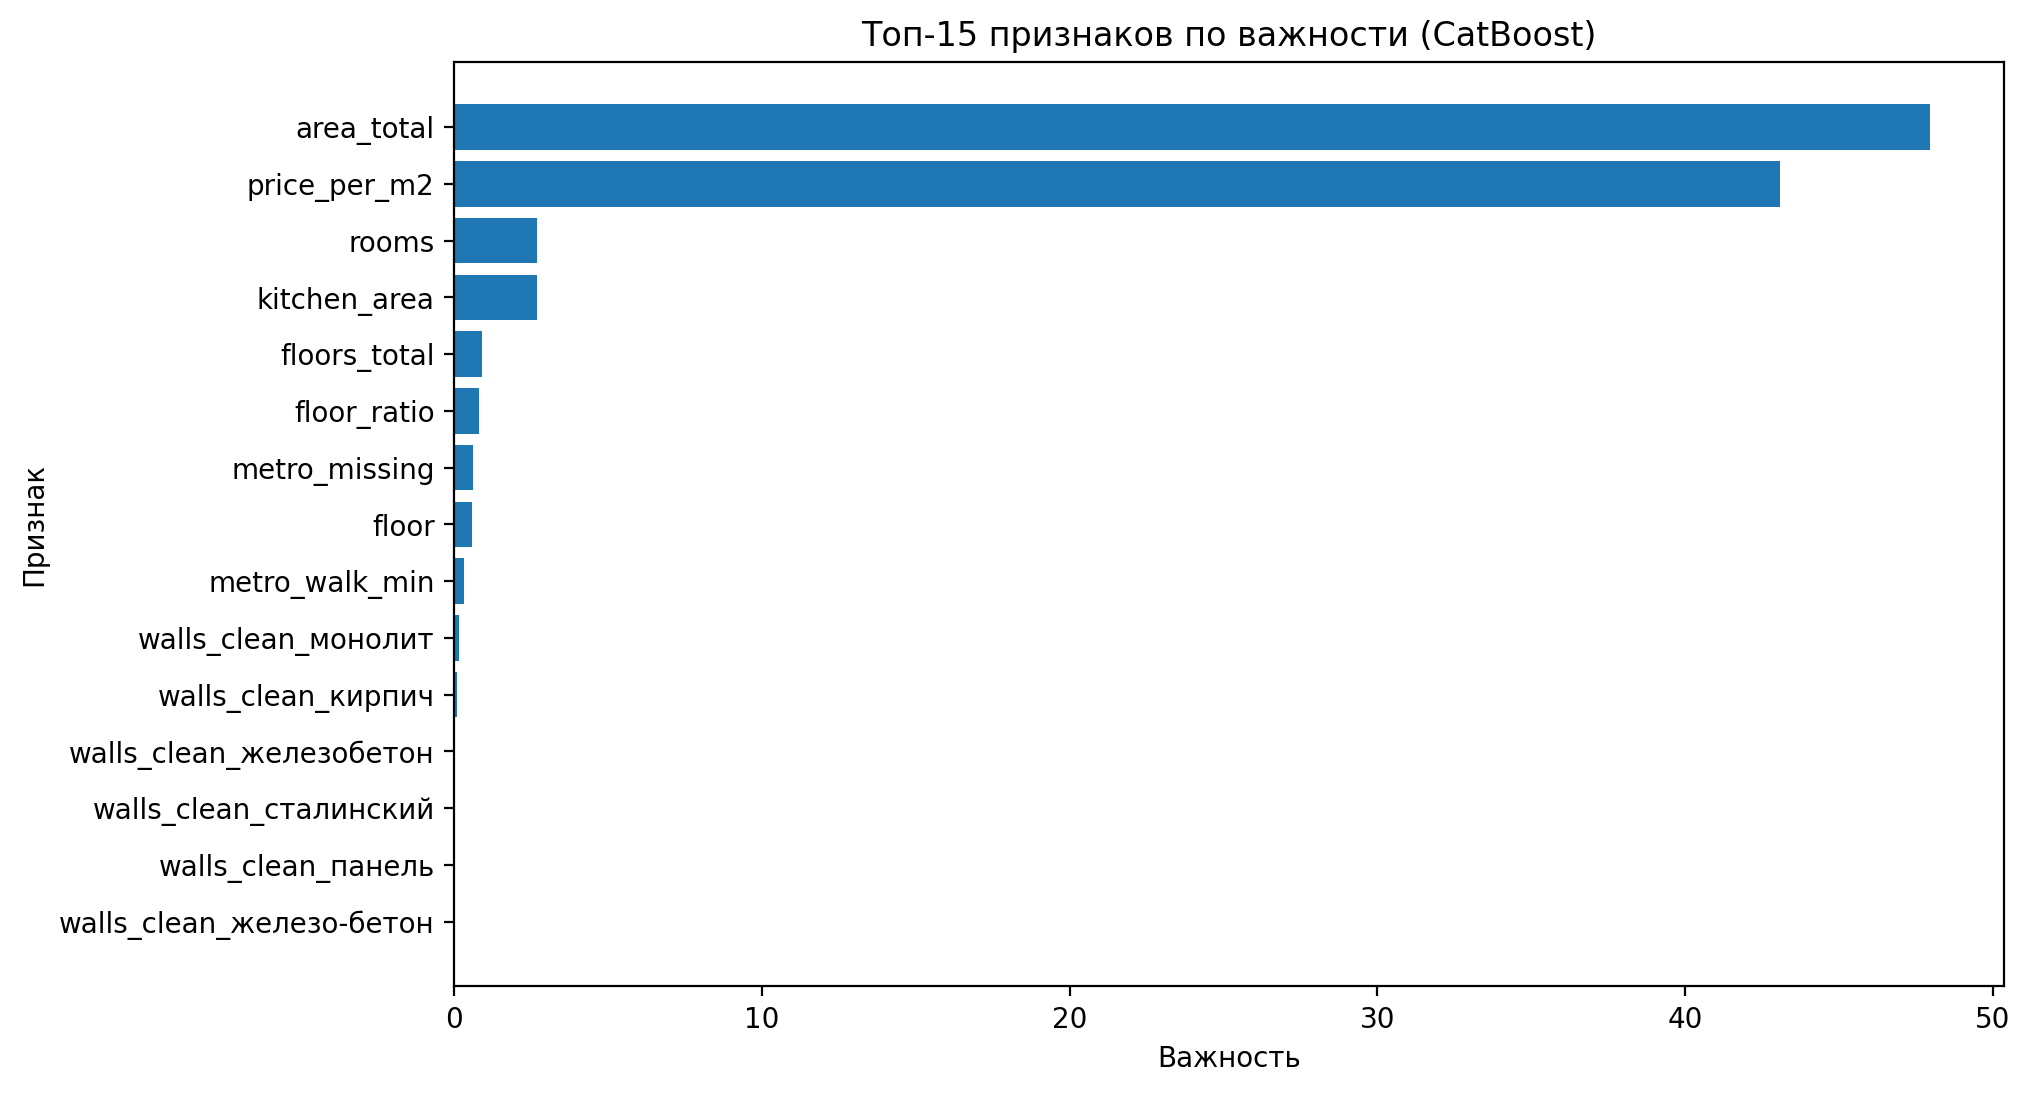

In [36]:
# 4. Feature importance
top_imp = importance.head(15)

fig = plt.figure(figsize=(10, 6))
plt.barh(top_imp["feature"][::-1], top_imp["importance"][::-1])
plt.xlabel("Важность")
plt.ylabel("Признак")
plt.title("Топ-15 признаков по важности (CatBoost)")
save_and_show(fig, "feature_importance.png")

In [37]:
# Фильтр адекватности для выделения действительно интересных объектов
result["price_per_m2_real"] = result["price_real"] / result["area_total"]

result_good = result[
    (result["price_real"] > 5_000_000) &
    (result["price_per_m2_real"] > 100_000) &
    (result["price_per_m2_real"] < 1_000_000)
].copy()

top_deals = result_good.sort_values("delta", ascending=False).head(20)

display(top_deals[[
    "price_real",
    "price_pred",
    "delta",
    "area_total",
    "rooms",
    "metro_walk_min",
    "price_per_m2_real"
]])

,price_real,price_pred,delta,area_total,rooms,metro_walk_min,price_per_m2_real
298,36000000,3.997870e+07,3.978704e+06,67.9,3.0,11.0,530191.458027
1234,14000000,1.765050e+07,3.650504e+06,81.9,0.0,20.0,170940.170940
664,39000000,4.223315e+07,3.233154e+06,67.0,2.0,5.0,582089.552239
2407,12500000,1.515594e+07,2.655941e+06,85.2,3.0,11.0,146713.615023
1618,39000000,4.154402e+07,2.544022e+06,86.0,2.0,10.0,453488.372093
1591,40700000,4.313546e+07,2.435461e+06,68.3,2.0,5.0,595900.439239
353,39600000,4.162866e+07,2.028665e+06,76.7,4.0,3.0,516297.262060
1519,44500000,4.635152e+07,1.851515e+06,74.0,3.0,10.0,601351.351351
2120,25500000,2.734752e+07,1.847522e+06,120.0,3.0,39.0,212500.000000
160,65000000,6.682816e+07,1.828157e+06,107.2,3.0,6.0,606343.283582


In [38]:
result["error_per_m2"] = result["abs_error"] / result["area_total"]

print("MAE per m²:", round(result["error_per_m2"].mean(), 2), "руб.")

MAE per m²: 9461.51 руб.


In [39]:
result["price_segment"] = pd.cut(
    result["price_real"],
    bins=[0, 10_000_000, 20_000_000, 40_000_000, 100_000_000, 500_000_000],
    labels=["до 10 млн", "10–20 млн", "20–40 млн", "40–100 млн", "100+ млн"]
)

segment_stats = result.groupby("price_segment", observed=False).agg(
    count=("price_real", "count"),
    mean_abs_error=("abs_error", "mean"),
    mean_ape=("ape", "mean"),
)

display(segment_stats)

,count,mean_abs_error,mean_ape
price_segment,,,
до 10 млн,24,5.298100e+05,11.009045
10–20 млн,237,2.012113e+05,1.360459
20–40 млн,173,4.645746e+05,1.561714
40–100 млн,38,1.496012e+06,2.543271
100+ млн,3,3.768353e+07,21.712323


In [40]:
print("Файлы в plots_model/:")
for p in sorted(MODEL_PLOTS_DIR.iterdir()):
    print("-", p.name)

print("\npredictions.csv exists:", PRED_FILE.exists())
print("feature_importance.csv exists:", IMPORTANCE_FILE.exists())

Файлы в plots_model/:
- abs_error_distribution.png
- ape_distribution.png
- feature_importance.png
- real_vs_pred.png

predictions.csv exists: True
feature_importance.csv exists: True


In [41]:
from google.colab import files
import shutil

# Архивируем графики модели
shutil.make_archive("plots_model", "zip", MODEL_PLOTS_DIR)

files.download(str(PRED_FILE))
files.download(str(IMPORTANCE_FILE))
files.download("plots_model.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>